In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load data
df = pd.read_csv(r"C:\Users\qurba\OneDrive\Desktop\Admission_Predict_Ver1.1.csv")
print("Data shape:", df.shape)
df.head()

Data shape: (500, 9)


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [3]:
# Data preprocessing
df = df.drop(columns=["Serial No."])

# Features and target
X = df.drop(columns=["Chance of Admit "])
y = df["Chance of Admit "]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (400, 7)
Test set: (100, 7)


In [4]:
# Polynomial Regression - Find optimal degree
degrees = [1, 2, 3, 4, 5]
train_errors = []
test_errors = []

for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)
    
    # Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # Calculate errors
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    train_errors.append(train_mae)
    test_errors.append(test_mae)
    
    print(f"Degree {degree}: Train MAE = {train_mae:.4f}, Test MAE = {test_mae:.4f}")

Degree 1: Train MAE = 0.0425, Test MAE = 0.0427
Degree 2: Train MAE = 0.0400, Test MAE = 0.0406
Degree 3: Train MAE = 0.0359, Test MAE = 0.0605
Degree 4: Train MAE = 0.0185, Test MAE = 0.2451
Degree 5: Train MAE = 0.0000, Test MAE = 0.4220


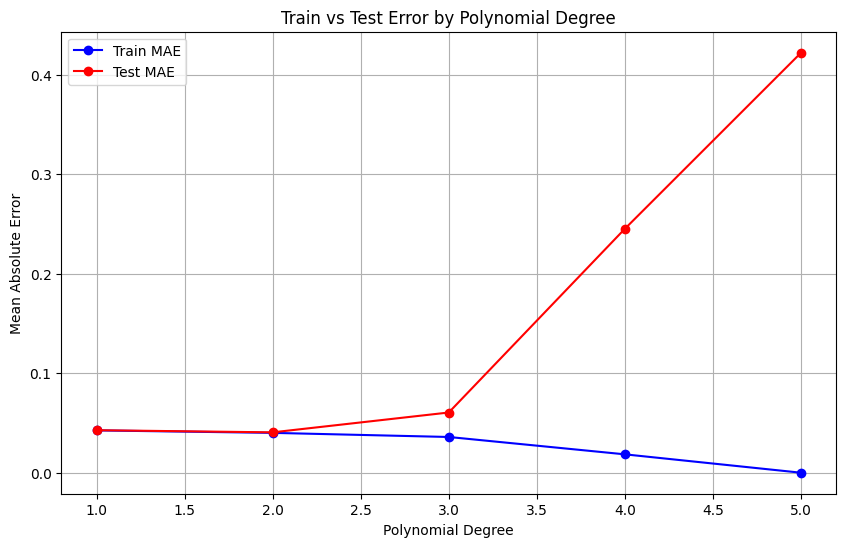

In [5]:
# Plot train vs test error
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, 'b-o', label='Train MAE')
plt.plot(degrees, test_errors, 'r-o', label='Test MAE')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Absolute Error')
plt.title('Train vs Test Error by Polynomial Degree')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Train final Polynomial Regression model with degree=2
best_degree = 2
poly_features = PolynomialFeatures(degree=best_degree)
X_train_poly = poly_features.fit_transform(X_train_scaled)
X_test_poly = poly_features.transform(X_test_scaled)

# Train model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predictions
y_train_pred = poly_model.predict(X_train_poly)
y_test_pred = poly_model.predict(X_test_poly)

print(f"Polynomial Regression (degree={best_degree}) Results:")
print(f"Number of features: {X_train_poly.shape[1]}")

Polynomial Regression (degree=2) Results:
Number of features: 36


In [7]:
# Model Evaluation
print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("\nTraining Set:")
print(f"  MAE:  {train_mae:.4f}")
print(f"  MSE:  {train_mse:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  R²:   {train_r2:.4f}")

# Test metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest Set:")
print(f"  MAE:  {test_mae:.4f}")
print(f"  MSE:  {test_mse:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R²:   {test_r2:.4f}")

MODEL EVALUATION

Training Set:
  MAE:  0.0400
  MSE:  0.0032
  RMSE: 0.0569
  R²:   0.8358

Test Set:
  MAE:  0.0406
  MSE:  0.0035
  RMSE: 0.0596
  R²:   0.8265


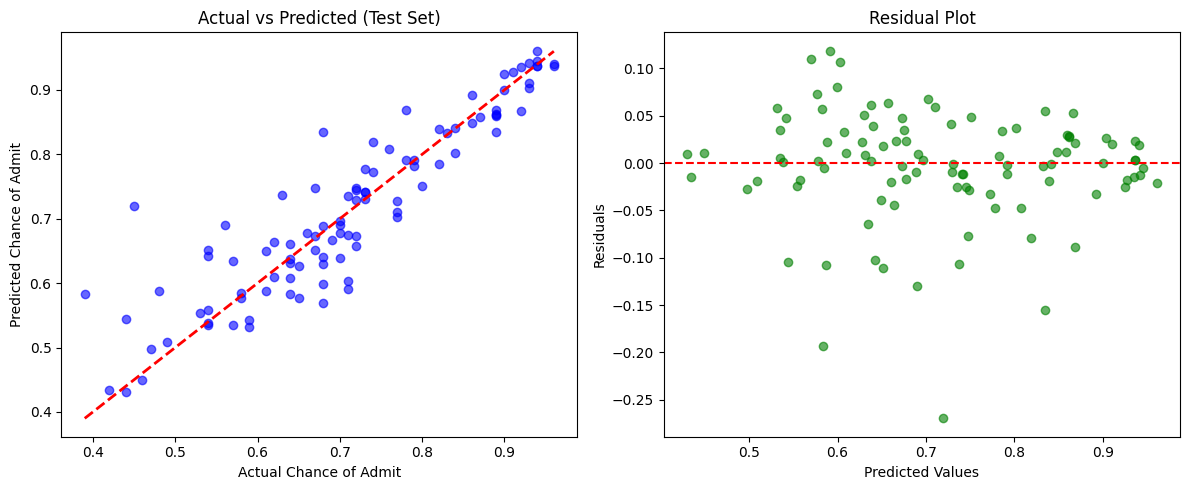

In [8]:
# Actual vs Predicted plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.title('Actual vs Predicted (Test Set)')

plt.subplot(1, 2, 2)
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.6, color='green')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

In [9]:
# Results DataFrame
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred,
    'Difference': np.abs(y_test.values - y_test_pred)
})
results_df = results_df.sort_values('Difference', ascending=False)
print("Top 10 largest prediction errors:")
results_df.head(10)

Top 10 largest prediction errors:


,Actual,Predicted,Difference
10,0.45,0.719550,0.269550
2,0.39,0.583174,0.193174
8,0.68,0.834664,0.154664
39,0.56,0.690130,0.130130
63,0.71,0.591240,0.118760
99,0.54,0.650891,0.110891
51,0.68,0.569518,0.110482
65,0.48,0.587428,0.107428
57,0.63,0.736860,0.106860
86,0.71,0.603149,0.106851
